# Tasks Week 6:

1. Fit a logistic regression model using all of the available inputs. Identify the direction of each effect
from the fitted coefficients. Compare these with the plots shown on the Guardian website. Do they
agree? Explain. (1 mark)

2. Present the value of each coefficient estimate and calculate the 95% confidence interval. Which input would you
say has the strongest effect and why? (0.5 mark) 


3. Using aic, perform a model selection to determine which factors are useful to predict the result of
the vote. You can use a ‘greedy’ input selection procedure, as follows: (i) select the best model with 1 input;
(ii) fixing that input, select the best two-input model (i.e. try all the other 4 inputs with the one you
selected first); (iii) select the best three-input model containing the first two inputs you chose, etc. At
each stage evaluate the quality of fit using aic and stop if this gets worse. (1 marks)

4. Perform cross-validation to directly test how well each model predicts new data. Remember to repeat the data splitting many times to check your results. Compare these to the values you get from AIC. (1 mark)

Q1:

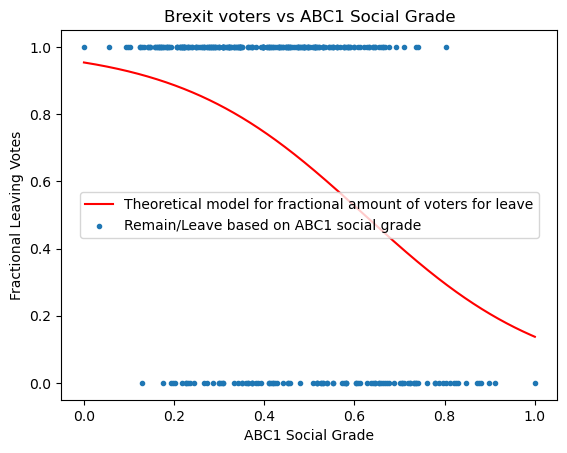

In [6]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import glm
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats
from sklearn.model_selection import train_test_split
from scipy.stats import norm
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn import tree

brexit = 'brexit.csv'
brexit_file = np.array(pd.read_csv(brexit, delimiter = ','))

brexit_vote = list(brexit_file[:, 5])
for i in range(len(brexit_vote)):
    if brexit_vote[i] == True:
        brexit_vote[i] = 1
    elif brexit_vote[i] == False:
        brexit_vote[i] = 0
    
leave = brexit_vote.count(True)
remain = brexit_vote.count(False)

df = pd.DataFrame({'abc_one':list(brexit_file[:,0]), 'notBornUK':list(brexit_file[:, 1]), 'medianIncome':list(brexit_file[:, 2]), 'medianAge':list(brexit_file[:, 3]), 'withHigherEd':list(brexit_file[:, 4]), 'voteBrexit':brexit_vote})
df.head()
# voteBrexit is True if more than 50% voted brexit in that particular region

Formula1 = 'voteBrexit ~ abc_one'
myglm1 = glm(Formula1, df, family=sm.families.Binomial()).fit()

Formula2 = 'voteBrexit ~ notBornUK'
myglm2 = glm(Formula2, df, family=sm.families.Binomial()).fit()

Formula3 = 'voteBrexit ~ medianIncome'
myglm3 = glm(Formula3, df, family=sm.families.Binomial()).fit()

Formula4 = 'voteBrexit ~ medianAge'
myglm4 = glm(Formula4, df, family=sm.families.Binomial()).fit()

Formula5 = 'voteBrexit ~ withHigherEd'
myglm5 = glm(Formula5, df, family=sm.families.Binomial()).fit()

def logistic_model(intercept, grad, x):
    return 1 / (1 + np.exp(-intercept - (grad * x)))
x_vals = np.linspace(0, 1, 1000)

# In these plots, the scatter model shows those who chose to remain/leave based on majority vote
# It doesn't show the actual fractional amount of voters, this is where the theoretical model is used
plt.plot(x_vals, logistic_model(myglm1.params[0], myglm1.params[1], x_vals), color='red', label='Theoretical model for fractional amount of voters for leave')
plt.scatter(brexit_file[:,0], brexit_vote, marker='.', label='Remain/Leave based on ABC1 social grade')
plt.title('Brexit voters vs ABC1 Social Grade')
plt.xlabel('ABC1 Social Grade')
plt.ylabel('Fractional Leaving Votes')
plt.legend(loc='center')
plt.show()

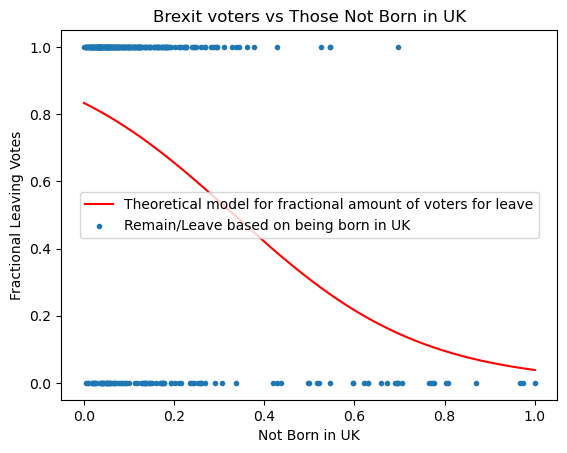

In [7]:
plt.plot(x_vals, logistic_model(myglm2.params[0], myglm2.params[1], x_vals), color='red', label='Theoretical model for fractional amount of voters for leave')
plt.scatter(brexit_file[:,1], brexit_vote, marker='.', label='Remain/Leave based on being born in UK')
plt.title('Brexit voters vs Those Not Born in UK')
plt.xlabel('Not Born in UK')
plt.ylabel('Fractional Leaving Votes')
plt.legend(loc='center')
plt.show()

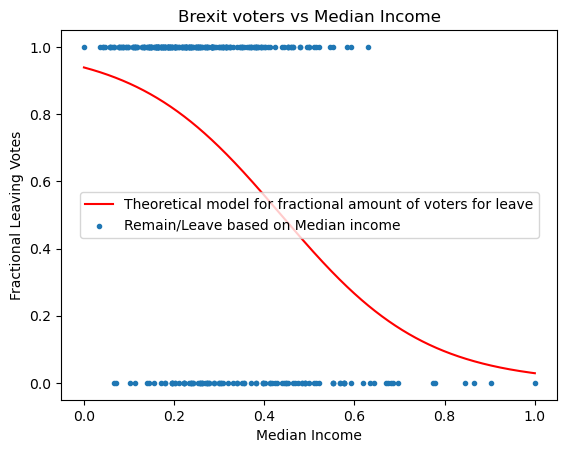

In [8]:
plt.plot(x_vals, logistic_model(myglm3.params[0], myglm3.params[1], x_vals), color='red', label='Theoretical model for fractional amount of voters for leave')
plt.scatter(brexit_file[:,2], brexit_vote, marker='.', label='Remain/Leave based on Median income')
plt.title('Brexit voters vs Median Income')
plt.xlabel('Median Income')
plt.ylabel('Fractional Leaving Votes')
plt.legend(loc='center')
plt.show()

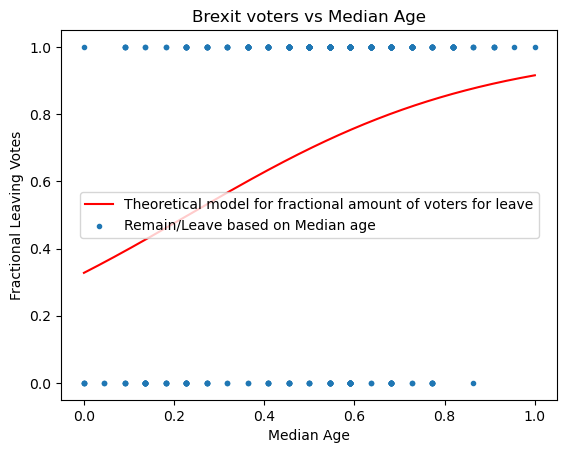

In [9]:
plt.plot(x_vals, logistic_model(myglm4.params[0], myglm4.params[1], x_vals), color='red', label='Theoretical model for fractional amount of voters for leave')
plt.scatter(brexit_file[:,3], brexit_vote, marker='.', label='Remain/Leave based on Median age')
plt.title('Brexit voters vs Median Age')
plt.xlabel('Median Age')
plt.ylabel('Fractional Leaving Votes')
plt.legend(loc='center')
plt.show()


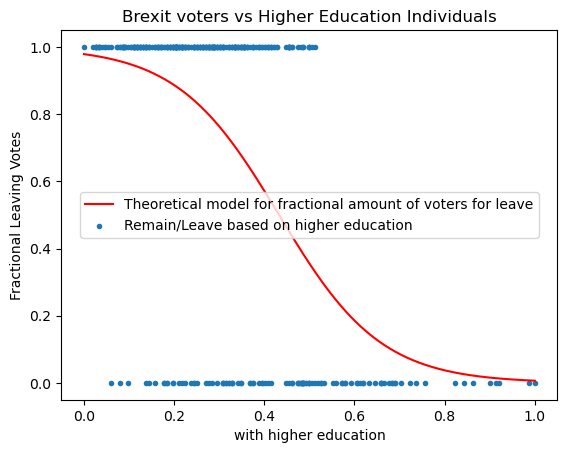

In [10]:
plt.plot(x_vals, logistic_model(myglm5.params[0], myglm5.params[1], x_vals), color='red', label='Theoretical model for fractional amount of voters for leave')
plt.scatter(brexit_file[:,4], brexit_vote, marker='.', label='Remain/Leave based on higher education')
plt.title('Brexit voters vs Higher Education Individuals')
plt.xlabel('with higher education')
plt.ylabel('Fractional Leaving Votes')
plt.legend(loc='center')
plt.show()

Q2:

In [11]:
zc = scipy.stats.norm.pdf(0.975)
estimate1 = myglm1.params[1]
standard_error1 = myglm1.bse[1]
CI_min1 = estimate1 - zc*standard_error1
CI_max1 = estimate1 + zc*standard_error1
print('confidence interval max for ABC1 Social Grade = ', CI_max1)
print('confidence interval min for ABC1 Social Grade = ', CI_min1)
print('ABC1 Social Grade coeff =', myglm1.params[1])
print('Intercept =', myglm1.params[0])
print('')

estimate2 = myglm2.params[1]
standard_error2 = myglm2.bse[1]
CI_min2 = estimate2 - zc*standard_error2
CI_max2 = estimate2 + zc*standard_error2
print('confidence interval max for not born in UK = ', CI_max2)
print('confidence interval min for not born in UK = ', CI_min2)
print('Those Not Born in UK coeff =', myglm2.params[1])
print('Intercept =', myglm2.params[0])
print('')

estimate3 = myglm3.params[1]
standard_error3 = myglm3.bse[1]
CI_min3 = estimate3 - zc*standard_error3
CI_max3 = estimate3 + zc*standard_error3
print('confidence interval max for median income = ', CI_max3)
print('confidence interval min for median income = ', CI_min3)
print('Median Income coeff =', myglm3.params[1])
print('Intercept =', myglm3.params[0])
print('')

estimate4 = myglm4.params[1]
standard_error4 = myglm4.bse[1]
CI_min4 = estimate4 - zc*standard_error4
CI_max4 = estimate4 + zc*standard_error4
print('confidence interval max for median age = ', CI_max4)
print('confidence interval min for median age = ', CI_min4)
print('Median Age coeff =', myglm4.params[1])
print('Intercept =', myglm4.params[0])
print('')

estimate5 = myglm5.params[1]
standard_error5 = myglm5.bse[1]
CI_min5 = estimate5 - zc*standard_error5
CI_max5 = estimate5 + zc*standard_error5
print('confidence interval max for higher education = ', CI_max5)
print('confidence interval min for higher education = ', CI_min5)
print('Higher Education coeff =', myglm5.params[1])
print('Intercept =', myglm5.params[0])
print('')

confidence interval max for ABC1 Social Grade =  -4.681302852563554
confidence interval min for ABC1 Social Grade =  -5.04512541749068
ABC1 Social Grade coeff = -4.863214135027117
Intercept = 3.0255712835814204

confidence interval max for not born in UK =  -4.630274944906114
confidence interval min for not born in UK =  -5.02468633224095
Those Not Born in UK coeff = -4.827480638573532
Intercept = 1.6091025968963948

confidence interval max for median income =  -6.023636405121705
confidence interval min for median income =  -6.47252265178394
Median Income coeff = -6.2480795284528226
Intercept = 2.732296003507205

confidence interval max for median age =  3.251323871820265
confidence interval min for median age =  2.9542542444152016
Median Age coeff = 3.1027890581177333
Intercept = -0.7189545198297074

confidence interval max for higher education =  -8.571535217399765
confidence interval min for higher education =  -9.098965916751188
Higher Education coeff = -8.835250567075477
Intercept

Higher education has the steepest correlation between education and Brexit voters, suggesting that it has the strongest causal effect on those who voted to leave. All coefficients for all models have confidence intervals that are comparibly the same siz as their coefficients, so the model that has the most effect on brexit voters is higher education.

Q3:

In [14]:
AIC1 = myglm1.aic
AIC2 = myglm2.aic
AIC3 = myglm3.aic
AIC4 = myglm4.aic
AIC5 = myglm5.aic
print('min AIC with one input (higher education) =', AIC5)
# The model that minimises the AIC with one input is the regression for higher education.
# Now we try a model that produces the lowest AIC with two inputs.

Formula6 = 'voteBrexit ~ withHigherEd + abc_one'
myglm6 = glm(Formula6, df, family=sm.families.Binomial()).fit()
# Below are the diferent AIC values when we introduce a second input:
# HigherEd + abc1 AIC: 286.54
# HigherEd + not born uk AIC: 310.36
# HigherEd + medianIncome AIC: 315.52
# HigherEd + medianAge AIC: 303.31
# For two inputs the lowest AIC value was generated using Higher education and the ABC1 social groups
print('lowest AIC for two inputs (HigherEd + abc1) =', myglm6.aic)

Formula7 = 'voteBrexit ~ withHigherEd + abc_one + medianAge'
myglm7 = glm(Formula7, df, family=sm.families.Binomial()).fit()
# Below are the diferent AIC values when we introduce a third input:
# HigherEd + abc1 + notBornUK AIC: 285.24
# HigherEd + abc1 + medianIncome AIC: 275.93
# HigherEd + abc1 + AIC: 271.93
print('lowest AIC for three inputs (HigherEd + abc1 + medianAge) =', myglm7.aic)

min AIC with one input (higher education) = 313.5604055904664
lowest AIC for two inputs (HigherEd + abc1) = 286.5454477003764
lowest AIC for three inputs (HigherEd + abc1 + medianAge) = 271.93170450949253


Q4:

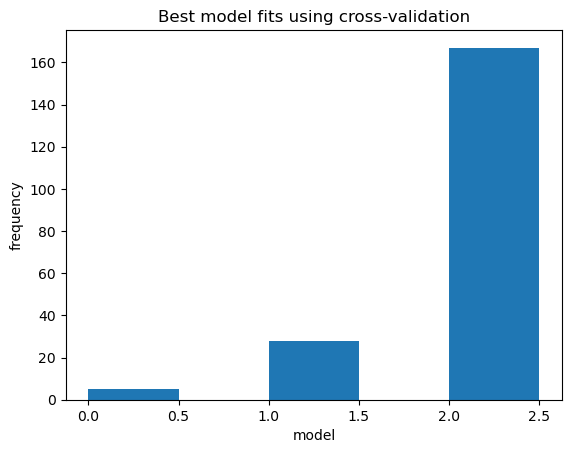

In [16]:
rep = 200
winner = []
for j in range(rep):
    train_data, test_data = train_test_split(df, test_size=0.5)
    model_selection = ['voteBrexit ~ withHigherEd', 'voteBrexit ~ withHigherEd + abc_one', 'voteBrexit ~ withHigherEd + abc_one + medianAge']
    predictive_log_likelihood = []
    for i in model_selection:
        training_data_fit = glm(i, train_data).fit()
        dispersion_parameter = np.sqrt(training_data_fit.scale)
        ypredict_mean = training_data_fit.predict(test_data)
        ypredict_meandf = pd.DataFrame({'ypredict_mean':ypredict_mean})
        predictive_log_likelihood.append(np.sum(norm.logpdf(test_data[['voteBrexit']], loc=ypredict_meandf[['ypredict_mean']], scale=dispersion_parameter)))
    winner.append(np.argmax(predictive_log_likelihood)) # Adds the index of the largest value to the empty winner array

model_number = np.arange(0, 3, 0.5)
plt.hist(winner, bins=model_number)
plt.title('Best model fits using cross-validation') # Histogram showing the frequencies that models fitted best regressions 1, 2 and 3.
plt.xlabel('model')
plt.ylabel('frequency')
plt.show()

The first bar shows the best AIC model using one input, the second using two and the third using three. In conformation with the lowest AIC value, cross validation shows that using the three inputs for: voteBrexit ~ withHigherEd + abc_one + medianAge, predicts the data for brexit voters best.

# Tasks Week 7:

5. Use the Scikit-Learn package to create a decision tree classification model. Visualise your model and intepret
the fitted model. (1 mark)

6. Using the ideas of cross-validation for decision tree's, can you improve your predictions ? (1 mark)

7. Compare your decision tree model and your logistic regression model. Do they attribute high importance
to the same factors? How do you intepret each model to explain the referendum vote? (1 mark)

8. Which model would you use if you were explaining the results for a newspaper article, and why? (0.5 mark)

Q5:

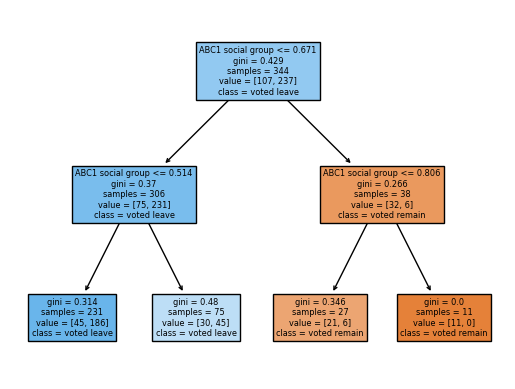

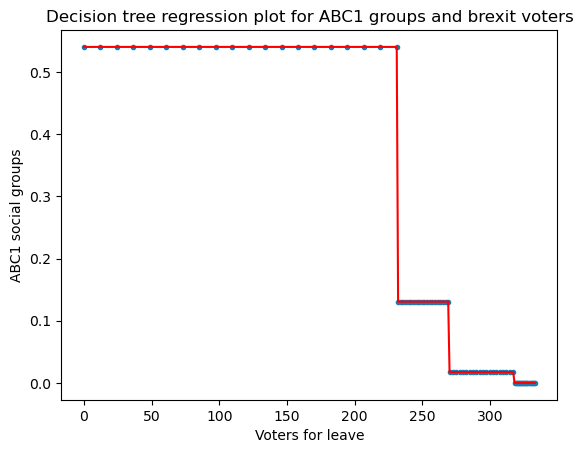

In [30]:
decisionTreeX1 = pd.DataFrame({'abc_one':list(brexit_file[:,0])})
decisionTreeX2 = pd.DataFrame({'notBornUK':list(brexit_file[:,1])})
decisionTreeX3 = pd.DataFrame({'medianIncome':list(brexit_file[:,2])})
decisionTreeX4 = pd.DataFrame({'medianAge':list(brexit_file[:, 3])})
decisionTreeX5 = pd.DataFrame({'withHigherEd':list(brexit_file[:, 4])})
decisionTreeY = pd.DataFrame({'voteBrexit':brexit_vote})

mytree1 = DecisionTreeClassifier(criterion='gini', max_depth=2)
mytree1.fit(decisionTreeX1, decisionTreeY)
export_graphviz(mytree1, out_file='dot_data', rounded=True, filled=True)
tree.plot_tree(mytree1, feature_names=['ABC1 social group'], filled=True, class_names=['voted remain', 'voted leave'])
plt.show()

num_voters = 344
ABC1_sample_node1 = 231
ABC1_leave_node1 = 186 / num_voters
ABC1_X1 = np.linspace(0, ABC1_sample_node1, 20)
ABC1_Y1 = ABC1_leave_node1 * np.ones(20)

ABC1_sample_node2 = 75
ABC1_leave_node2 = 45 / num_voters
ABC1_X2 = np.linspace(ABC1_sample_node1+1, num_voters-ABC1_sample_node2, 20)
ABC1_Y2 = ABC1_leave_node2 * np.ones(20)

ABC1_sample_node3 = 27
ABC1_leave_node3 = 6 / num_voters
ABC1_X3 = np.linspace(num_voters-ABC1_sample_node2+1, num_voters-ABC1_sample_node3, 20)
ABC1_Y3 = ABC1_leave_node3 * np.ones(20)

ABC1_sample_node4 = 11
ABC1_leave_node4 = 0 / num_voters
ABC1_X4 = np.linspace(num_voters-ABC1_sample_node3+1, num_voters-ABC1_sample_node4, 20)
ABC1_Y4 = ABC1_leave_node4 * np.ones(20)

plot_ABC1_x = np.concatenate([ABC1_X1, ABC1_X2, ABC1_X3, ABC1_X4])
ys_ABC1 = np.concatenate([ABC1_Y1, ABC1_Y2, ABC1_Y3, ABC1_Y4])
plt.scatter(plot_ABC1_x, ys_ABC1, marker='.')
plt.plot(plot_ABC1_x, ys_ABC1, color='red')
plt.xlabel('Voters for leave')
plt.ylabel('ABC1 social groups')
plt.title('Decision tree regression plot for ABC1 groups and brexit voters')
plt.show()

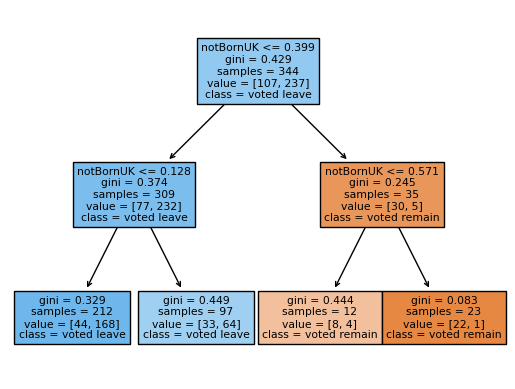

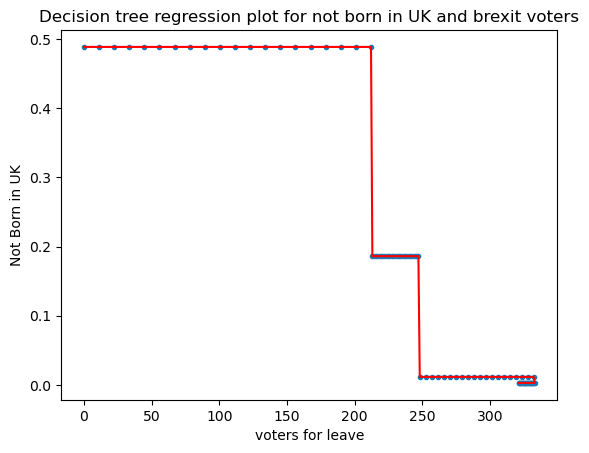

In [31]:
mytree2 = DecisionTreeClassifier(criterion='gini', max_depth=2)
mytree2.fit(decisionTreeX2, decisionTreeY)
export_graphviz(mytree2, out_file='dot_data', rounded=True, filled=True)
tree.plot_tree(mytree2, feature_names=['notBornUK'], filled=True, class_names=['voted remain', 'voted leave'])
plt.show()

# Now the decision tree plot for not born in UK
NBUK_sample_node1 = 212
NBUK_leave_node1 = 168 / num_voters
NBUK_X1 = np.linspace(0, NBUK_sample_node1, 20)
NBUK_Y1 = NBUK_leave_node1 * np.ones(20)

NBUK_sample_node2 = 97
NBUK_leave_node2 = 64 / num_voters
NBUK_X2 = np.linspace(NBUK_sample_node1+1, num_voters-NBUK_sample_node2, 20)
NBUK_Y2 = NBUK_leave_node2 * np.ones(20)

NBUK_sample_node3 = 12
NBUK_leave_node3 = 4 / num_voters
NBUK_X3 = np.linspace(num_voters-NBUK_sample_node2+1, num_voters-NBUK_sample_node3, 20)
NBUK_Y3 = NBUK_leave_node3 * np.ones(20)

NBUK_sample_node4 = 23
NBUK_leave_node4 = 1 / num_voters
NBUK_X4 = np.linspace(num_voters-NBUK_sample_node3+1, num_voters-NBUK_sample_node4, 20)
NBUK_Y4 = NBUK_leave_node4 * np.ones(20)

plot_NBUK_x = np.concatenate([NBUK_X1, NBUK_X2, NBUK_X3, NBUK_X4])
ys_NBUK = np.concatenate([NBUK_Y1, NBUK_Y2, NBUK_Y3, NBUK_Y4])
plt.scatter(plot_NBUK_x, ys_NBUK, marker='.')
plt.plot(plot_NBUK_x, ys_NBUK, color='red')
plt.xlabel('voters for leave')
plt.ylabel('Not Born in UK')
plt.title('Decision tree regression plot for not born in UK and brexit voters')
plt.show()

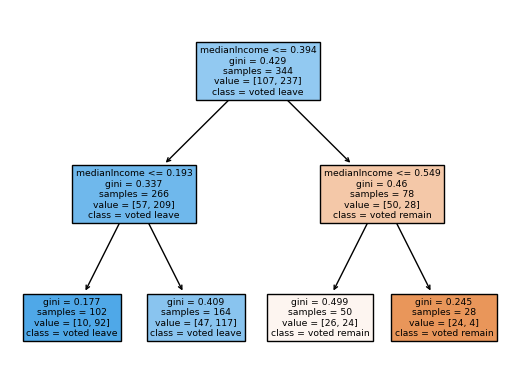

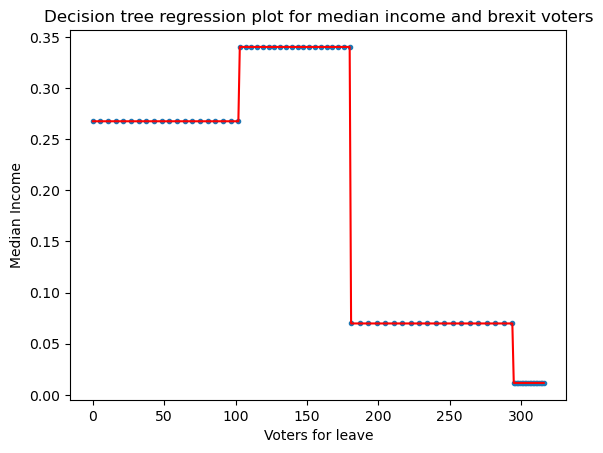

In [29]:
mytree3 = DecisionTreeClassifier(criterion='gini', max_depth=2)
mytree3.fit(decisionTreeX3, decisionTreeY)
export_graphviz(mytree3, out_file='dot_data', rounded=True, filled=True)
tree.plot_tree(mytree3, feature_names=['medianIncome'], filled=True, class_names=['voted remain', 'voted leave'])
plt.show()

# Now the decision tree plot for median income
MEDIN_sample_node1 = 102
MEDIN_leave_node1 = 92 / num_voters
MEDIN_X1 = np.linspace(0, MEDIN_sample_node1, 20)
MEDIN_Y1 = MEDIN_leave_node1 * np.ones(20)

MEDIN_sample_node2 = 164
MEDIN_leave_node2 = 117 / num_voters
MEDIN_X2 = np.linspace(MEDIN_sample_node1+1, num_voters-MEDIN_sample_node2, 20)
MEDIN_Y2 = MEDIN_leave_node2 * np.ones(20)

MEDIN_sample_node3 = 50
MEDIN_leave_node3 = 24 / num_voters
MEDIN_X3 = np.linspace(num_voters-MEDIN_sample_node2+1, num_voters-MEDIN_sample_node3, 20)
MEDIN_Y3 = MEDIN_leave_node3 * np.ones(20)

MEDIN_sample_node4 = 28
MEDIN_leave_node4 = 4 / num_voters
MEDIN_X4 = np.linspace(num_voters-MEDIN_sample_node3+1, num_voters-MEDIN_sample_node4, 20)
MEDIN_Y4 = MEDIN_leave_node4 * np.ones(20)

plot_MEDIN_x = np.concatenate([MEDIN_X1, MEDIN_X2, MEDIN_X3, MEDIN_X4])
ys_MEDIN = np.concatenate([MEDIN_Y1, MEDIN_Y2, MEDIN_Y3, MEDIN_Y4])
plt.scatter(plot_MEDIN_x, ys_MEDIN, marker='.')
plt.plot(plot_MEDIN_x, ys_MEDIN, color='red')
plt.xlabel('Voters for leave')
plt.ylabel('Median Income')
plt.title('Decision tree regression plot for median income and brexit voters')
plt.show()

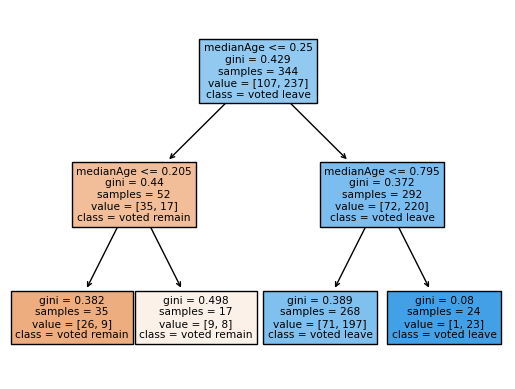

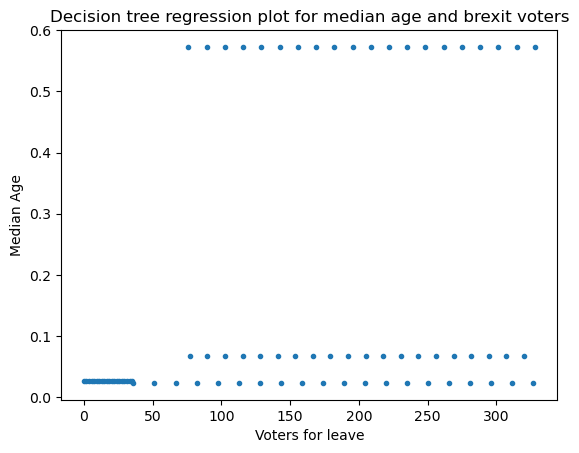

In [32]:
mytree4 = DecisionTreeClassifier(criterion='gini', max_depth=2)
mytree4.fit(decisionTreeX4, decisionTreeY)
export_graphviz(mytree4, out_file='dot_data', rounded=True, filled=True)
tree.plot_tree(mytree4, feature_names=['medianAge'], filled=True, class_names=['voted remain', 'voted leave'])
plt.show()

# Now the decision tree plot for median age
MEDAG_sample_node1 = 35
MEDAG_leave_node1 = 9 / num_voters
MEDAG_X1 = np.linspace(0, MEDAG_sample_node1, 20)
MEDAG_Y1 = MEDAG_leave_node1 * np.ones(20)

MEDAG_sample_node2 = 17
MEDAG_leave_node2 = 8 / num_voters
MEDAG_X2 = np.linspace(MEDAG_sample_node1+1, num_voters-MEDAG_sample_node2, 20)
MEDAG_Y2 = MEDAG_leave_node2 * np.ones(20)

MEDAG_sample_node3 = 268
MEDAG_leave_node3 = 197 / num_voters
MEDAG_X3 = np.linspace(num_voters-MEDAG_sample_node2+1, num_voters-MEDAG_sample_node3, 20)
MEDAG_Y3 = MEDAG_leave_node3 * np.ones(20)

MEDAG_sample_node4 = 24
MEDAG_leave_node4 = 23 / num_voters
MEDAG_X4 = np.linspace(num_voters-MEDAG_sample_node3+1, num_voters-MEDAG_sample_node4, 20)
MEDAG_Y4 = MEDAG_leave_node4 * np.ones(20)

plot_MEDAG_x = np.concatenate([MEDAG_X1, MEDAG_X2, MEDAG_X3, MEDAG_X4])
ys_MEDAG = np.concatenate([MEDAG_Y1, MEDAG_Y2, MEDAG_Y3, MEDAG_Y4])
plt.scatter(plot_MEDAG_x, ys_MEDAG, marker='.') 
plt.xlabel('Voters for leave')
plt.ylabel('Median Age')
plt.title('Decision tree regression plot for median age and brexit voters')
plt.show()

(The fitted plot wasn't suitable for median age so the scatter is shown)

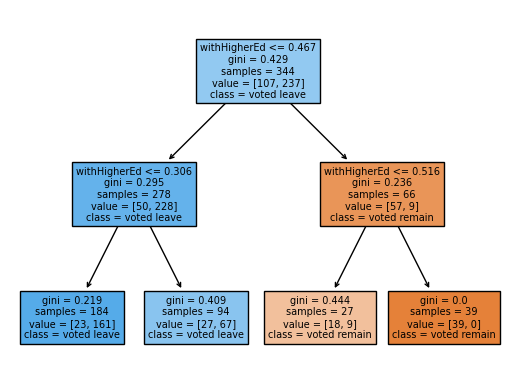

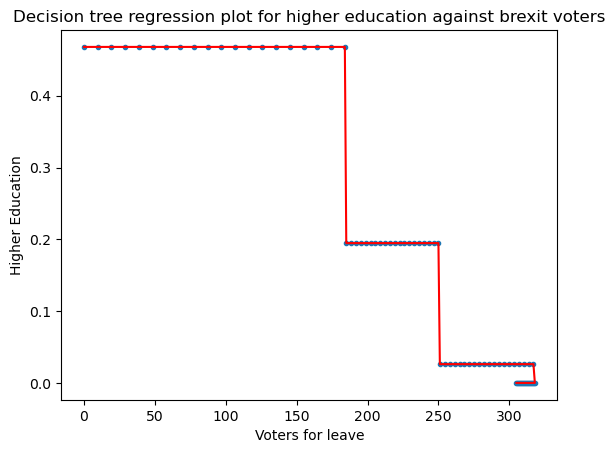

In [33]:
mytree5 = DecisionTreeClassifier(criterion='gini', max_depth=2)
mytree5.fit(decisionTreeX5, decisionTreeY)
export_graphviz(mytree5, out_file='dot_data', rounded=True, filled=True)
tree.plot_tree(mytree5, feature_names=['withHigherEd'], filled=True, class_names=['voted remain', 'voted leave'])
plt.show()

# Now the decision tree plot for higher education
HIGED_sample_node1 = 184
HIGED_leave_node1 = 161 / num_voters
HIGED_X1 = np.linspace(0, HIGED_sample_node1, 20)
HIGED_Y1 = HIGED_leave_node1 * np.ones(20)

HIGED_sample_node2 = 94
HIGED_leave_node2 = 67 / num_voters
HIGED_X2 = np.linspace(HIGED_sample_node1+1, num_voters-HIGED_sample_node2, 20)
HIGED_Y2 = HIGED_leave_node2 * np.ones(20)

HIGED_sample_node3 = 27
HIGED_leave_node3 = 9 / num_voters
HIGED_X3 = np.linspace(num_voters-HIGED_sample_node2+1, num_voters-HIGED_sample_node3, 20)
HIGED_Y3 = HIGED_leave_node3 * np.ones(20)

HIGED_sample_node4 = 39
HIGED_leave_node4 = 0 / num_voters
HIGED_X4 = np.linspace(num_voters-HIGED_sample_node3+1, num_voters-HIGED_sample_node4, 20)
HIGED_Y4 = HIGED_leave_node4 * np.ones(20)

plot_HIGED_x = np.concatenate([HIGED_X1, HIGED_X2, HIGED_X3, HIGED_X4])
ys_HIGED = np.concatenate([HIGED_Y1, HIGED_Y2, HIGED_Y3, HIGED_Y4])
plt.scatter(plot_HIGED_x, ys_HIGED, marker = '.')
plt.plot(plot_HIGED_x, ys_HIGED, color='red')
plt.xlabel('Voters for leave')
plt.ylabel('Higher Education')
plt.title('Decision tree regression plot for higher education against brexit voters')
plt.show()

Q6:

Cross validation may be used to pick the best fitting model out of the decision tree regressions. Cross validation with the best decision tree regression and the logistic regression model could be used to identify which of the two fitting types works best, logistic regression or decision trees. To improve the predictions for Brexit voters, a similar approach with the decision trees can be made alike to what was done in task 4, we could integrate more variables into the decision tree to see if it lowers the AIC, and then cross validate to check if introducing 2 or 3 variables into the decision tree strengthens the regression.

Q7:

The decision tree regressions were consistent with the logistic regression models with the exception of the plot for median age, which due to the largely even spread of voters who chose to remain and leave over all age groups, led to an unsuccesful plot using the decision tree. Overall the plots for the decision trees showed the same trends as the logistic regression, it also showed where different slices of the data contributed more to the leaving votes. The decision tree works well when there is little data overlapping, but in the case of median age where there was a largely even spread agross the age range, the decision tree didn't succesfully produce a representative plot. To make the plot more accurate, the depth of the decision tree could be increased.

Q8:

For a newspaper article, the most suitable model to use would be the logistic regression, it is the simplest and most easy model to interpret. The logistic regression model can also easily work with multiple inputs to show how combinations of variables affected brexit. However the best logistic regression models should be justified using the AIC and cross validation as the raw plots alone are not sufficient enough to decide what correlation is best. With actual data on voting percentages an even more accurate model can also be formed off a logistic regression.

# Bonus:

My code has shown two different types of regression used to model brexit voters as a function of different parameters. The decision tree model and the logistic regression model both agree with each other on the whole for my raw data with the exception for the median age model which was justified and explained with the context of why decision trees fail to fit raw data that has a lot of overlapping. My AIC and cross validation techniques identified the best logistic regression model with clear representation of the order of which models were best (shown by the histogram).

# Self-Assessment:

The week 6 tasks involved using a logistic regression model to fit a set of raw data that was either true or false dependent on whether the individual voted for or against brexit. The strength of the models were then validated using AIC and cross validation, alongside cross validation to find the best model to reduce the AIC when using 3 inputs. It was found that the best model using three inputs significantly improved the AIC compared to using just one input.

The week 7 tasks involved using the decision tree model to again model the raw data for brexit voters. A similar trend was found when using decision tree modelling, with the exception of the median age model that had too much of a weak correlation, or too much of an even spread over the age range for the decision tree to compute an effective regression. The decision tree was good for identifying specific splits in the data or areas where brexit voters were voting, but overall is was suggested that for an outside perspective, logistic regression is more simple and intuitive for a newspaper article.